<a href="https://colab.research.google.com/github/rhyan-rpone/ai-and-data_analysis-notebooks/blob/main/departamento_medico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação das bibliotecas e base de dados

In [ ]:
import os
import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, AveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
xray_directory = '/content/drive/MyDrive/Departamento_Medico/Dataset'

In [ ]:
os.listdir(xray_directory)

['.DS_Store', '0', '2', '3', '1']

In [ ]:
# Temos a pasta dataset, aonde dentro dela temos as imagens de treinamento, dividias por classes 0,1,2,3
# A pasta de teste abriga as imagens de teste que vamos usar pra testar o modelo
# A primeira classe que temos nas imagens é covid-19 (classe 0)
# A segunda classe mostra imagens normais (classe 1)
# A terceira classe são exames de pneumonia geral (classe 2)
# A quarta classe são exames de pneumonia bacterial (classe 3)

In [ ]:
image_generator = ImageDataGenerator(rescale=1./255)

# as imagens estao no formato RGB, e os pixels das imagens sao represemtados por numeros inteiros entre 0 e 255, quanto mais proximo de zero, mais escurdo a imagem, quanto mais longe, mais clara
# para que a rede neural procese mais rápido, vamos colocar esses valores em uma escala de 0 e 1, por isso estamos fazendo esse reescalonamento

In [ ]:
train_generator = image_generator.flow_from_directory(batch_size = 40, directory=xray_directory, shuffle=True, target_size=(256,256), class_mode='categorical', subset='training')

Found 532 images belonging to 4 classes.


In [ ]:
133 * 4

532

In [ ]:
# Esse objeto fez a leitura das imagens e já fez também a divisão das classes

In [ ]:
532 / 40

13.3

In [ ]:
# Nós definimos o numero 40 como batch_size, teremos um total de 13 batches e em cada batch processamos 40 imagens

In [ ]:
train_images, train_labels = next(train_generator)

In [ ]:
train_images.shape

(40, 256, 256, 3)

In [ ]:
# temos 40 imagens, cada uma tem 256 de altura por 256 de largura, e 3 canais, um pro vermelho, um azul e um verde, padrão RGB
# train_labels mostra as classes pra cada uma das imagens, vamos criar uma variavel com o nome correspondente a classe

In [ ]:
# Covid19 - 1 0 0 0
# Normal  - 0 1 0 0
# Viral   - 0 0 1 0
# Bacterial - 0 0 0 1

labels_names = {0: 'Covid-19', 1: 'Normal', 2: 'Pneumonia Geral', 3: 'Pneumonia Bacteriana'}

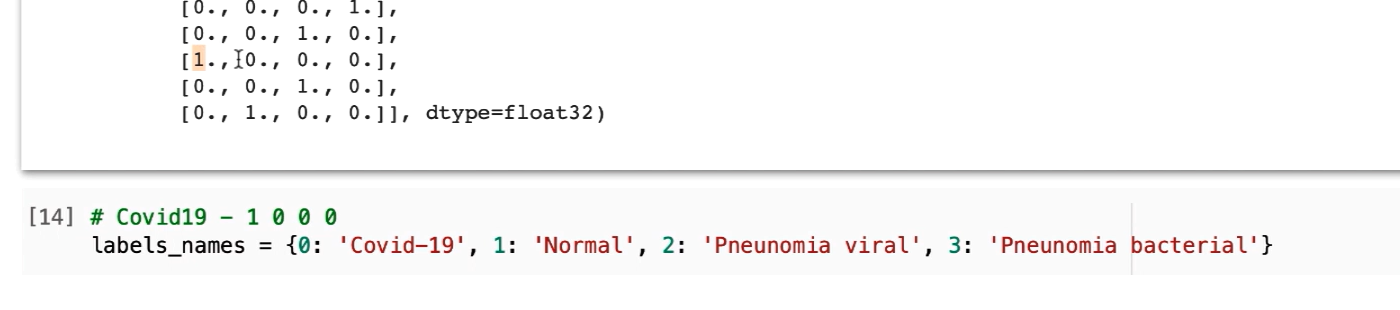

In [ ]:
# Podemos observar como o tensorflow mostra a classificação dessa forma, definimos as 4 classes e o valor 1 fica na classe da imagem selecionada, o 0 representa o negativo, o 1 o positivo pra uma determinada classe.

In [ ]:
train_labels[0]

array([1., 0., 0., 0.], dtype=float32)

In [ ]:
np.argmax(train_labels[0])

np.int64(0)

# Visualização dos dados

In [ ]:
np.arange(0, 36)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35])

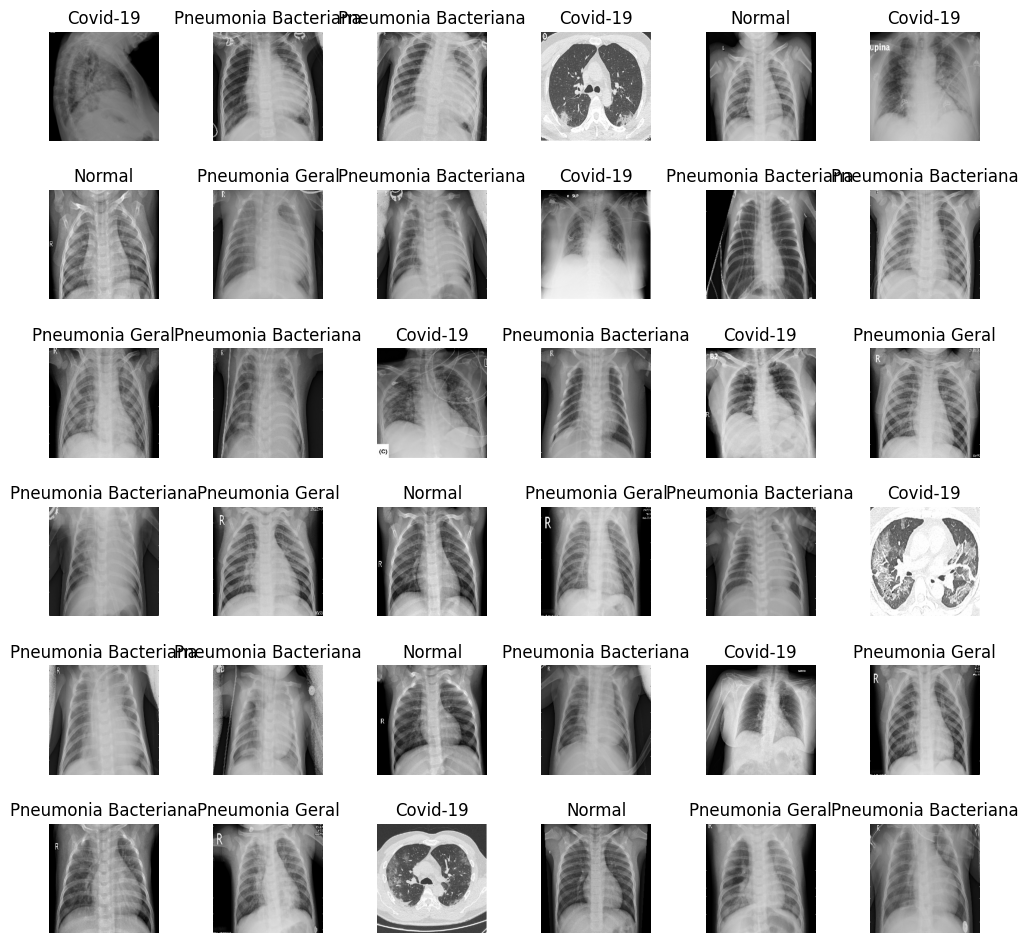

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, 36):
    axes[i].imshow(train_images[i])
    axes[i].set_title(labels_names[np.argmax(train_labels[i])])
    axes[i].axis('off')
plt.subplots_adjust(wspace=0.5)

# Carregamento da Rede Neural Pré-Treinada

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_tensor = Input (shape=(256,256,3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
len(base_model.layers)

175

In [ ]:
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [ ]:
# vamos fazer um for pra percorrer todas as camadas e vamos ndicar que não será possível fazer o treinamento nessas camadas
# como vamos iniciar o treinamento da rede neural com nossas imagens, precisamos definir esse parametro para que os pesos não sejam iniciados do zero, ainde podemos colocar para que nao seja executada as 10 ultimas camadas, elas não serão retornadas.

# Construção e Treinamento do Modelo de Deep Learning

In [ ]:
# Nesta etapa, criamos a parte final da rede neural, responsável por transformar
# as características aprendidas pela CNN em uma previsão da classe da imagem.
#
# Primeiro, pegamos a saída do modelo pré-treinado (base_model), que contém
# diversas características importantes da imagem, como formas, texturas e padrões.
head_model = base_model.output

# AveragePooling2D reduz o tamanho dessas informações, mantendo apenas o que é
# mais importante. Isso diminui a quantidade de dados que serão processados.
head_model = AveragePooling2D(pool_size=(2, 2))(head_model)

# Flatten transforma esses dados em um único vetor (uma lista de números),
# para que possam ser utilizados pelas próximas camadas da rede.
head_model = Flatten()(head_model)

# A primeira camada Dense possui 256 neurônios e aprende a combinar as
# características extraídas pela CNN para identificar padrões relevantes.
head_model = Dense(256, activation='relu')(head_model)

# Dropout desativa aleatoriamente 20% dos neurônios durante o treinamento.
# Isso evita que a rede "decore" os exemplos e melhora sua capacidade de
# reconhecer novas imagens.
head_model = Dropout(0.2)(head_model)

# Uma segunda camada Dense continua refinando o aprendizado antes da classificação.
head_model = Dense(256, activation='relu')(head_model)

# Outro Dropout é aplicado para aumentar ainda mais a capacidade de generalização.
head_model = Dropout(0.2)(head_model)

# Por fim, a camada de saída possui 4 neurônios, um para cada classe do problema.
# A função Softmax calcula a probabilidade de a imagem pertencer a cada classe,
# e a classe com maior probabilidade será a resposta do modelo.
head_model = Dense(4, activation='softmax')(head_model)

In [ ]:
model = Model(inputs = base_model.input, outputs = head_model)

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate = 1e-4),
              metrics = ['accuracy'])

In [ ]:
checkpointer = ModelCheckpoint(filepath='weights.keras')

In [ ]:
train_generator = image_generator.flow_from_directory(batch_size = 4, directory=xray_directory,
                                                      shuffle = True, target_size=(256, 256),
                                                      class_mode = 'categorical', subset='training')

Found 532 images belonging to 4 classes.


In [ ]:
history = model.fit(train_generator, epochs = 25, callbacks=[checkpointer])

Epoch 1/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8477 - loss: 0.4828
Epoch 2/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8383 - loss: 0.5034
Epoch 3/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8346 - loss: 0.4403
Epoch 4/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.8402 - loss: 0.4504
Epoch 5/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8553 - loss: 0.4551
Epoch 6/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8496 - loss: 0.4418
Epoch 7/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8759 - loss: 0.3978
Epoch 8/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.8816 - loss: 0.3812
Epoch 9/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8741 - loss: 0.4160
Epoch 10/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8797 - loss: 0.3602
Epoch 11/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8778 - loss: 0.3334
Epoch 12/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 

# Avaliação da Rede Neural

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

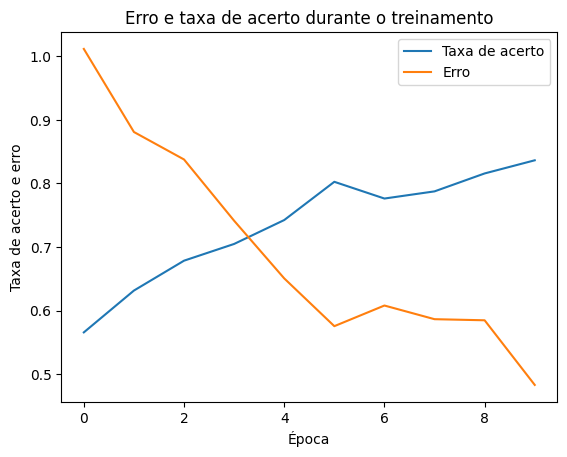

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.title('Erro e taxa de acerto durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Taxa de acerto e erro')
plt.legend(['Taxa de acerto', 'Erro']);

In [ ]:
test_directory = '/content/drive/MyDrive/Departamento_Medico/Test'

In [ ]:
os.listdir(test_directory)

['0', '1', '2', '3']

In [ ]:
test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_directory(batch_size = 40, directory=test_directory,
                                                      shuffle = True, target_size=(256, 256),
                                                      class_mode = 'categorical')

Found 40 images belonging to 4 classes.


In [ ]:
evaluate = model.evaluate(test_generator)
evaluate

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5750 - loss: 1.1217


[1.1216566562652588, 0.574999988079071]

In [ ]:
prediction = []
original = []
image = []

for i in range(len(os.listdir(test_directory))):
  for item in os.listdir(os.path.join(test_directory, str(i))):
    #print(os.listdir(os.path.join(test_directory, str(i))))
    img = cv2.imread(os.path.join(test_directory, str(i), item))
    img = cv2.resize(img, (256, 256))
    image.append(img)
    img = img / 255
    img = img.reshape(-1, 256, 256, 3)
    predict = model.predict(img)
    predict = np.argmax(predict)
    prediction.append(predict)
    original.append(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
prediction

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(2)]

In [ ]:
original

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

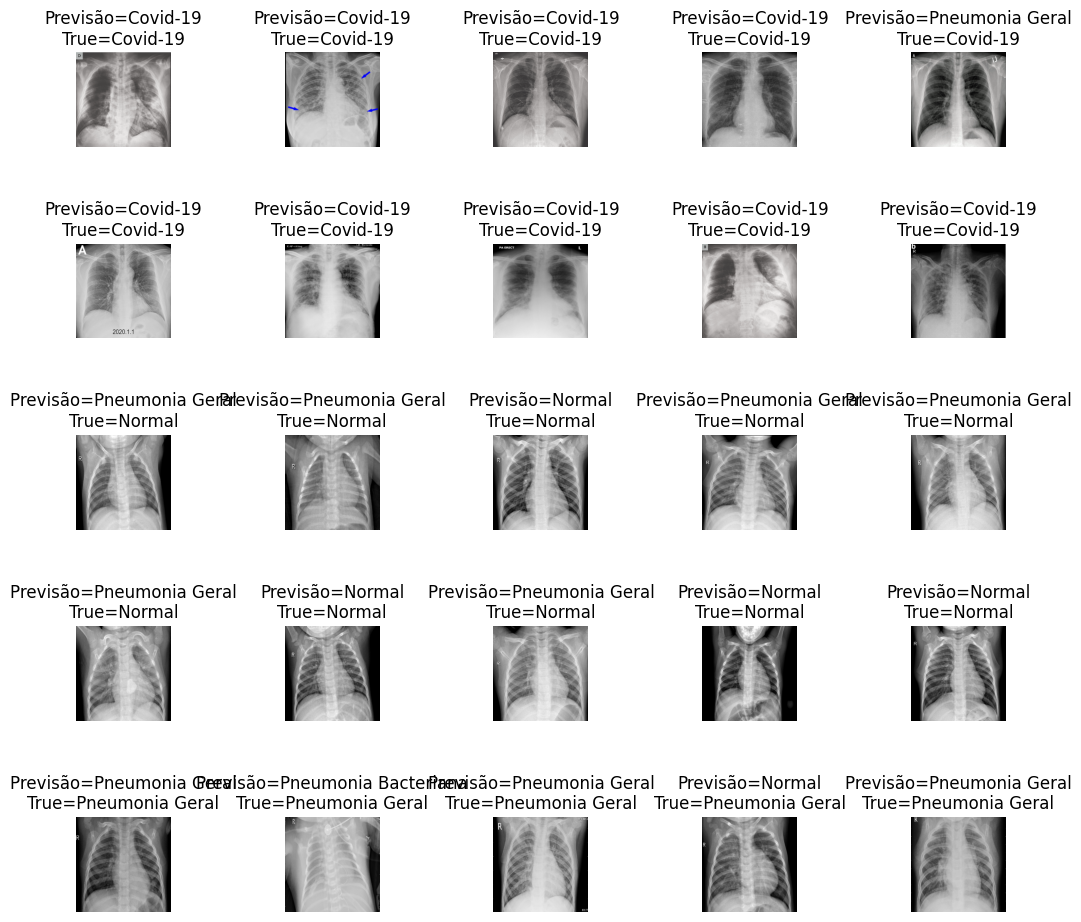

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(12,12))
axes = axes.ravel()
for i in np.arange(0, 25):
  axes[i].imshow(image[i])
  axes[i].set_title('Previsão={}\nTrue={}'.format(str(labels_names[prediction[i]]), str(labels_names[original[i]])))
  axes[i].axis('off')
plt.subplots_adjust(wspace = 1.2)

In [ ]:
labels_names

{0: 'Covid-19', 1: 'Normal', 2: 'Pneumonia Geral', 3: 'Pneumonia Bacteriana'}

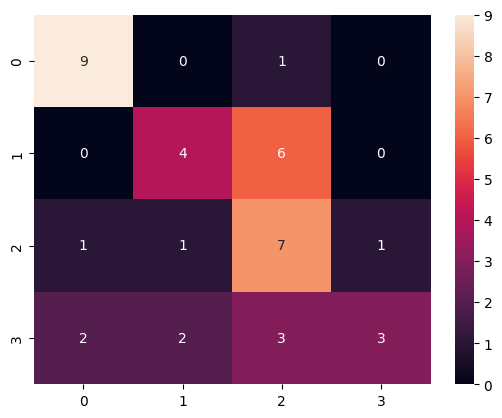

In [ ]:
cm = confusion_matrix(original, prediction)
sns.heatmap(cm, annot=True);

In [ ]:
print(classification_report(original, prediction))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.57      0.40      0.47        10
           2       0.41      0.70      0.52        10
           3       0.75      0.30      0.43        10

    accuracy                           0.57        40
   macro avg       0.62      0.57      0.56        40
weighted avg       0.62      0.57      0.56        40



# Classificação de somente uma imagem

In [ ]:
from keras.models import load model
model_loaded = load_model('/content/weights.keras')

In [ ]:
model_loaded.summary

NameError: name 'model_loaded' is not defined